The objective of this notebook is to group customers into different segments based on their purchasing and behavioral patterns using the K-Means clustering algorithm.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv("Customer_Segmentation_Cleaned.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,27.6,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,27.6,8.8,2.0,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,8.4,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [4]:
features = [
    "Membership_Years",
    "Login_Frequency",
    "Session_Duration_Avg",
    "Pages_Per_Session",
    "Cart_Abandonment_Rate",
    "Wishlist_Items",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Discount_Usage_Rate",
    "Returns_Rate",
    "Email_Open_Rate",
    "Lifetime_Value",
    "Payment_Method_Diversity",
    "Mobile_App_Usage"
]
X = df[features]

Standardize the features before applying K-Means.
Not every column is useful for clustering.
Only numerical customer behavior features are selected because K-Means works best with numerical data.
These features describe customer purchasing behavior, website activity, and customer value.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

StandardScaler converts all features to a similar scale with a mean of 0 and a standard deviation of 1.
This helps K-Means treat every feature equally.
Use the Elbow Method to determine the optimal number of clusters.

In [6]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

Before applying K-Means, we need to decide how many customer groups (clusters) should be created.
The Elbow Method calculates the Within-Cluster Sum of Squares (WCSS) for different values of K.
WCSS measures how closely the data points are grouped within each cluster.
A lower WCSS indicates better clustering, but increasing K always reduces WCSS.
The best value of K is chosen where the graph forms an "elbow".

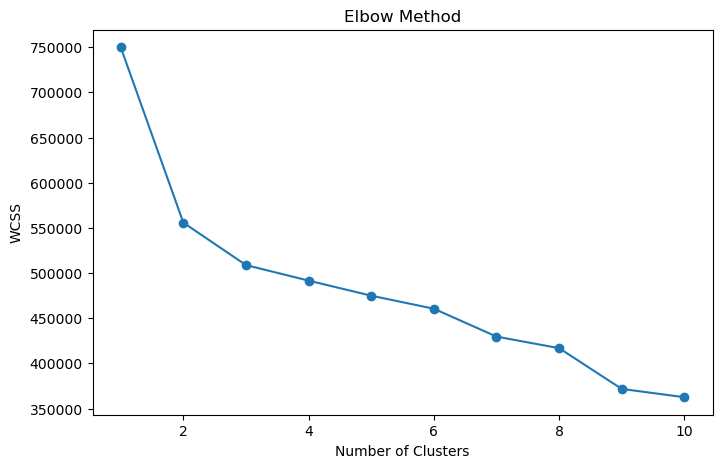

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The Elbow Curve is drawn using the WCSS values.
Look for the point where the decrease in WCSS starts becoming slower.
This point is called the elbow point and represents the optimal number of customer clusters.
For most customer segmentation datasets, the best value is usually 4 or 5.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

The Elbow Method graph helps determine the optimal number of clusters.
From the graph, there is a sharp decrease in WCSS from K = 1 to K = 3. After K = 3, the curve becomes flatter, indicating that adding more clusters provides only a small improvement.
Therefore, the optimal number of clusters is 3.
These three clusters represent different groups of customers based on their purchasing and behavioral patterns.

In [9]:
df["Cluster"].value_counts().sort_index()

Cluster
0     9438
1    21035
2    19527
Name: count, dtype: int64

Count the number of customers in each cluster.

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

The dataset contains many features, making it difficult to visualize.
PCA reduces the dataset into two dimensions while preserving most of the important information.
This allows us to create a simple scatter plot of the customer segments.

The scatter plot displays the customer segments created by the K-Means algorithm after reducing the data to two dimensions using PCA.

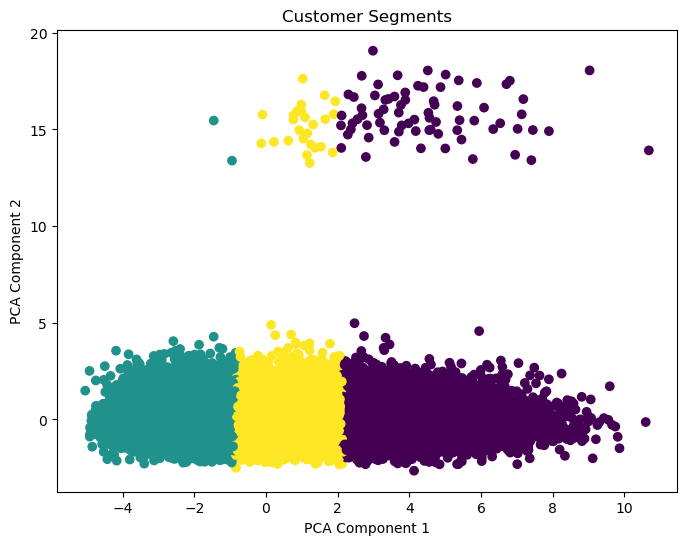

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"]
)
plt.title("Customer Segments")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [12]:
df.groupby("Cluster")[[
    "Lifetime_Value",
    "Total_Purchases",
    "Average_Order_Value",
    "Membership_Years"
]].mean().round(2)

,Lifetime_Value,Total_Purchases,Average_Order_Value,Membership_Years
Cluster,,,,
0,2446.10,21.93,130.43,2.99
1,873.86,8.08,119.06,2.99
2,1565.18,14.27,123.95,2.97


Cluster 0 – High-Value Customers
- Highest Lifetime Value
- Highest Total Purchases
- Highest Average Order Value
  
Cluster 1 – Low-Value Customers
- Lowest Lifetime Value
- Lowest Total Purchases
- Lowest Average Order Value
  
Cluster 2 – Medium-Value Customers
- Moderate spending and purchase frequency

In [14]:
df.to_csv("Customer_Segmentation_With_Clusters.csv", index=False)

Save the dataset after adding the Cluster column.
This new dataset will be used in Power BI to build customer segmentation dashboards and generate business insights.